# Gold Sentiment Dataset — Exploratory Data Analysis

Baseline exploration of the dataset used in `src/training.py`. Covers:

- Class distribution and imbalance
- Headline length by class
- Past vs Future information breakdown (a key data-quality gap in the original training code)
- Sample headlines per class

Helper functions (`load_data`, `summarize_*`, `show_sample_headlines`) live in `src/eda.py`.
Visualisation is done inline here.


In [1]:
%matplotlib inline
import sys

sys.path.insert(0, 'src')

import matplotlib.pyplot as plt
import numpy as np

from eda import (
    CLASSES,
    COLORS,
    load_data,
    show_sample_headlines,
    summarize_classes,
    summarize_headline_lengths,
    summarize_past_future,
)

data = load_data(csv_path='./data/gold-dataset-sinha-khandait.csv')
data['word_count'] = data['News'].str.split().str.len()
n_classes = data['Price Sentiment'].nunique()
print(f'Loaded {len(data):,} rows, {n_classes} classes.')

Loaded 10,570 rows, 4 classes.


## 1. Class Distribution


=== Class Distribution ===
  positive    4412  (41.7%)
  negative    3814  (36.1%)
  none        1968  (18.6%)
  neutral      376  (3.6%)
  TOTAL      10570



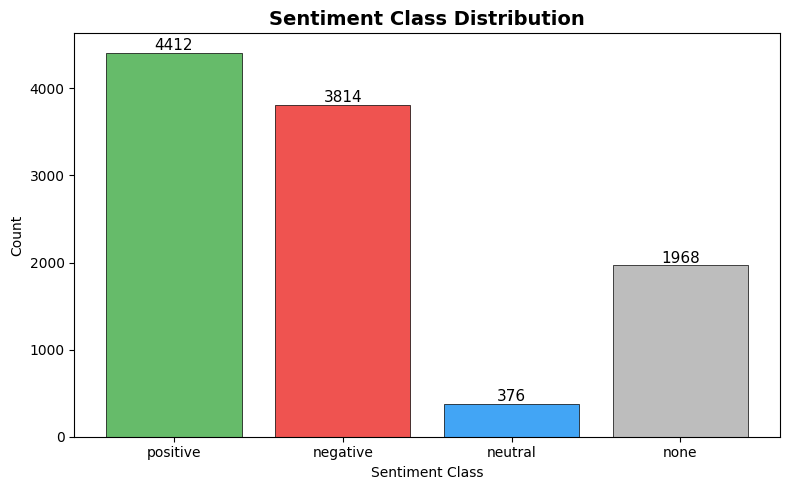

In [2]:
summarize_classes(data=data)

counts = data["Price Sentiment"].value_counts().reindex(CLASSES)
bar_colors = [COLORS[cls] for cls in CLASSES]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x=CLASSES,
    height=counts.values,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title(label="Sentiment Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel(xlabel="Sentiment Class")
ax.set_ylabel(ylabel="Count")

for i, count in enumerate(counts.values):
    ax.text(x=i, y=count + 30, s=str(count), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## 2. Headline Length by Class


=== Headline Word Count by Class ===
  positive    min=3, max=20, mean=8.9, median=9
  negative    min=1, max=19, mean=8.9, median=9
  neutral     min=3, max=16, mean=8.4, median=8
  none        min=2, max=21, mean=9.1, median=9



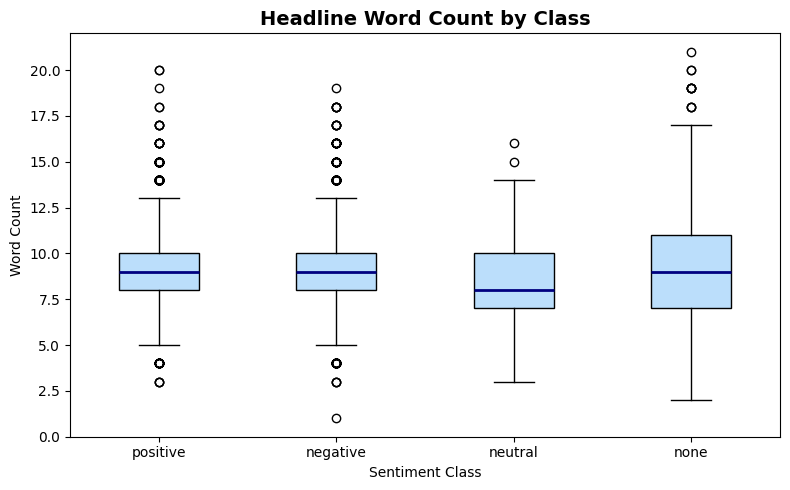

In [ ]:
summarize_headline_lengths(data=data)

lengths = [data[data["Price Sentiment"] == cls]["word_count"].values for cls in CLASSES]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    x=lengths,
    tick_labels=CLASSES,
    patch_artist=True,
    boxprops={"facecolor": "#bbdefb"},
    medianprops={"color": "navy", "linewidth": 2},
)

ax.set_title(
    label="Headline Word Count by Class",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel(xlabel="Sentiment Class")
ax.set_ylabel(ylabel="Word Count")

plt.tight_layout()
plt.show()

## 3. Past vs Future Information

The dataset flags each headline as reporting a historical price move (`Past Information=1`)
or making a forward-looking prediction (`Future Information=1`). The training code does not
filter or weight by this flag. The chart below shows whether that matters.


=== Past vs Future Information Breakdown by Class ===
  Past=1 -> headline reports a historical price move.
  Future=1 -> headline makes a forward-looking prediction.

  positive (n=4412):
    Past only:    4353  (98.7%)
    Future only:    59  (1.3%)
    Both:            0  (0.0%)
    Neither:         0  (0.0%)

  negative (n=3814):
    Past only:    3775  (99.0%)
    Future only:    39  (1.0%)
    Both:            0  (0.0%)
    Neither:         0  (0.0%)

  neutral (n=376):
    Past only:     327  (87.0%)
    Future only:    49  (13.0%)
    Both:            0  (0.0%)
    Neither:         0  (0.0%)

  none (n=1968):
    Past only:    1796  (91.3%)
    Future only:   171  (8.7%)
    Both:            1  (0.1%)
    Neither:         0  (0.0%)



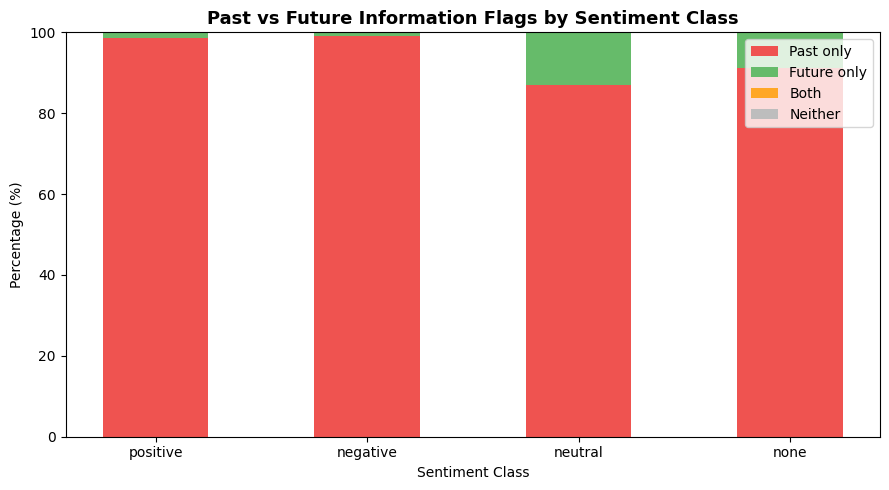

In [ ]:
summarize_past_future(data=data)

past_only_pcts = []
future_only_pcts = []
both_pcts = []
neither_pcts = []

for cls in CLASSES:
    subset = data[data["Price Sentiment"] == cls]
    n = len(subset)
    n_past = int(subset["Past Information"].sum())
    n_future = int(subset["Future Information"].sum())
    n_both = int(
        ((subset["Past Information"] == 1) & (subset["Future Information"] == 1)).sum()
    )

    n_neither = int(
        ((subset["Past Information"] == 0) & (subset["Future Information"] == 0)).sum()
    )

    past_only_pcts.append(100 * (n_past - n_both) / n)
    future_only_pcts.append(100 * (n_future - n_both) / n)
    both_pcts.append(100 * n_both / n)
    neither_pcts.append(100 * n_neither / n)

x_pos = np.arange(len(CLASSES))
width = 0.5
bottom_future = np.array(past_only_pcts)
bottom_both = bottom_future + np.array(future_only_pcts)
bottom_neither = bottom_both + np.array(both_pcts)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x=x_pos,
    height=past_only_pcts,
    width=width,
    label="Past only",
    color="#ef5350",
)

ax.bar(
    x=x_pos,
    height=future_only_pcts,
    width=width,
    bottom=bottom_future,
    label="Future only",
    color="#66bb6a",
)

ax.bar(
    x=x_pos,
    height=both_pcts,
    width=width,
    bottom=bottom_both,
    label="Both",
    color="#ffa726",
)

ax.bar(
    x=x_pos,
    height=neither_pcts,
    width=width,
    bottom=bottom_neither,
    label="Neither",
    color="#bdbdbd",
)

ax.set_xticks(ticks=x_pos)
ax.set_xticklabels(labels=CLASSES)

ax.set_title(
    label="Past vs Future Information Flags by Sentiment Class",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel(xlabel="Sentiment Class")
ax.set_ylabel(ylabel="Percentage (%)")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Sample Headlines per Class


In [5]:
show_sample_headlines(data=data, n=3)

=== 3 Sample Headlines per Class ===

  POSITIVE:
    - gold not done yet, expert says sept to bring all-time high
    - gold futures close higher as the dollar weakens
    - Gold gains as a investors seek safe harbor from geopolitical woes

  NEGATIVE:
    - Gold futures trade lower ahead of Comex settlement
    - april gold falls $10.60, or 0.8%, to settle at $1,337.30/oz
    - gold falls on dollar strength, lower stocks

  NEUTRAL:
    - Gold prices little changed after housing, import data
    - gold, silver may trade on rangebound note:angel commodities
    - gold futures hover near 4-year lows on stronger dollar

  NONE:
    - MCX gold may touch Rs 28,500 per 10 gm
    - gold jewellery sales expected to double this akshaya tritiya
    - gold, silver and oil markets hope for better year

